# Solve the 1D Linear Schrödinger equation using a discrete time Physics Informed Neural Network

In the following, we will solve the dimensionless 1D Schrödinger equation with inhomogeneous Dirichlet boundary conditions using a Physics Informed Neural Network (PINN).
This boundary values problem can be stated as

$$ i \hbar \partial_t \psi(x, t) = \left(-\frac{\hbar^2}{2m}\partial_x^2 + V(x, t)\right) \psi(x, t) $$
with
$$ \psi(x, t = t_0) \equiv \psi_0(x) \qquad \psi(x=x_l, t) \equiv \psi_L(t) \qquad \psi(x=x_r, t) \equiv \psi_R(t) $$
for $t \in [t_0, t_1]$ and $x \in [x_l, x_r]$ and $\psi \in C_2([t_0, t_1] \times [x_l, x_r], \mathbb{C})$.

In contrast to the continuous time approach in `linear_schroedinger_1d.ipynb`, we do not approximate $\psi(x, t)$ in both spatial and temporal dimensions here. Instead, we follow the discrete time approach of the original PINN paper (Raissi, Perdikaris & Karniadakis, J. Comput. Phys. 378, 2019) and apply an implicit Runge-Kutta (IRK) scheme with $q$ stages to take a single time step of size $\Delta t = t_1 - t_0$.
To this end, we write the Schrödinger equation as

$$ \partial_t \psi = \mathcal{N}[\psi] \qquad \text{with} \qquad \mathcal{N}[\psi] \equiv \frac{i \hbar}{2m} \partial_x^2 \psi - \frac{i}{\hbar} V \psi $$
The IRK scheme then reads

$$ \psi^{n+c_j}(x) = \psi^n(x) + \Delta t \sum_{k=1}^q a_{jk} \mathcal{N}[\psi^{n+c_k}](x), \qquad j = 1, \dots, q $$
$$ \psi^{n+1}(x) = \psi^n(x) + \Delta t \sum_{k=1}^q b_k \mathcal{N}[\psi^{n+c_k}](x) $$
where $\psi^{n+c_j}(x) \equiv \psi(x, t_0 + c_j \Delta t)$ are the stages and $a_{jk}$, $b_k$ and $c_j$ are the coefficients of the Butcher tableau.

We approximate the $q+1$ functions $\left[\psi^{n+c_1}(x), \dots, \psi^{n+c_q}(x), \psi^{n+1}(x)\right]$ via a neural network $\psi_{\theta}(x)$ that takes a single input parameter and outputs $2(q+1)$ output parameters - the real and imaginary part of the wave function at each stage and at the final time. Note that we only approximate the wave function in the spatial dimension, the temporal dimension is handled by the IRK scheme.
Rearranging the scheme, each of the $q+1$ outputs has to reproduce the known initial condition

$$ \psi^n_j(x) \equiv \psi^{n+c_j}_{\theta}(x) - \Delta t \sum_{k=1}^q a_{jk} \mathcal{N}[\psi^{n+c_k}_{\theta}](x) \overset{!}{=} \psi_0(x), \qquad j = 1, \dots, q $$
$$ \psi^n_{q+1}(x) \equiv \psi^{n+1}_{\theta}(x) - \Delta t \sum_{k=1}^q b_k \mathcal{N}[\psi^{n+c_k}_{\theta}](x) \overset{!}{=} \psi_0(x) $$
In total, the loss functional then contains two terms:
 - The mean squared misfit of the $q+1$ reconstructions $\psi^n_j$ w.r.t. initial conditions - this is where the PDE enters
 - The mean squared misfit w.r.t. boundary conditions at the $q$ stage times $t_0 + c_j \Delta t$ and at $t_1$

It is minimised over a number of points that are randomly sampled from $[x_l, x_r]$ at $t_0$. There are no collocation points in time - the dynamics are fully encoded in the IRK scheme.
We use the Gauss-Legendre IRK weights with $q = 256$ stages from the PINN paper. Their temporal error is $\mathcal{O}(\Delta t^{2q})$, i.e. far below machine precision, which is why a single large time step suffices.

This notebook heavily draws on the implementation of the PINN approach published by Jan Blechschmidt under https://github.com/janblechschmidt/PDEsByNNs/ (MIT license) and on the discrete time implementation published by Maziar Raissi under https://github.com/maziarraissi/PINNs (MIT license).

### Includes

In [1]:
!pip install -q tf-keras

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"   # must be set before importing tensorflow

In [2]:
# import libraries
import os
import random

import numpy as np
import tensorflow as tf

# use single precision
rtype = 'float32'
ctype = 'complex64'
tf.keras.backend.set_floatx(rtype)

"""Neon plot style with glowing lines"""
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use('dark_background')

colors = [
    '#08F7FE',  # teal/cyan
    '#FE53BB',  # pink
    '#F5D300',  # yellow
    '#00ff41',  # matrix green
    '#FF00FF',  # magenta
    '#FFA500',  # orange
    '#00FFFF',  # cyan
]
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)
mpl.rcParams['image.cmap'] = 'magma'

# publication-ready fonts: large, bold labels and ticks, no titles
mpl.rcParams.update({
    'font.size':          16,
    'font.weight':        'bold',
    'axes.labelsize':     20,
    'axes.labelweight':   'bold',
    'axes.labelpad':      8,
    'axes.linewidth':     1.5,
    'axes.edgecolor':     '#CCCCCC',
    'xtick.labelsize':    16,
    'ytick.labelsize':    16,
    'xtick.major.width':  1.5,
    'ytick.major.width':  1.5,
    'xtick.major.size':   6,
    'ytick.major.size':   6,
    'legend.fontsize':    15,
    'legend.frameon':     True,
    'legend.framealpha':  0.8,
    'legend.facecolor':   'black',
    'legend.edgecolor':   '#CCCCCC',
    'mathtext.fontset':   'dejavusans',
    'mathtext.default':   'bf',      # bold upright math so labels match the bold text
    'lines.linewidth':    2.5,
    'lines.markersize':   9,
    'figure.figsize':     (9, 6),
    'savefig.facecolor':  'black',
})

# style for training/prediction data points drawn on top of the glowing lines
points = dict(marker='X', s=90, c='white', edgecolors='black', linewidths=0.8, zorder=5)

# layers of increasingly wide, increasingly transparent lines create the glow
linewidths     = np.logspace(-5, 5, 20, base=2)
transparencies = np.linspace(1, 0, 20)


def glow(x, y, ax=None, **kwargs):
    """Plot a line with a neon-glow effect; kwargs go to the main line."""
    ax = ax or plt.gca()
    line, = ax.plot(x, y, **kwargs)
    for lw, alpha in zip(linewidths, transparencies):
        ax.plot(x, y, lw=lw, c=line.get_color(), alpha=alpha * 0.3)
    return line


def save(name, fig=None):
    """Save the figure as figures/<name>.png."""
    os.makedirs('figures', exist_ok=True)
    (fig or plt.gcf()).savefig(f'figures/{name}.png', dpi=200, bbox_inches='tight')

## Make training reproducible
Credit to Christian Kruschel at towardsdatascience (https://towardsdatascience.com/debugging-neural-networks-abdc6273a3f1).

In [ ]:
seed = 0

# Built-in Python
random.seed(seed)  # Derandomize hashes of strings, bytes and datetime objects os.environ['PYTHONHASHSEED']=str(seed)  # Numpy
np.random.seed(seed)  # Tensorflow
tf.random.set_seed(seed)
os.environ['TF_DETERMINISTIC_OPS'] = '1' # determininistic convolution and max-pool
tf.config.threading.set_inter_op_parallelism_threads(1)

### Define the test problem

In the first test, we consider a plane wave.

In [6]:
t0    = tf.constant(0.0) # initial time
t1    = tf.constant(np.pi) # final time
xl    = tf.constant(0.0)  # left domain boundary
xr    = tf.constant(1.0)  # right domain boundary
hbar  = tf.constant(1.0)    # physical constants
mass  = tf.constant(1.0)    # physical constants
chbar = tf.cast(hbar, ctype)
cmass = tf.cast(mass, ctype)

# define plane wave
# complex numbers are treated as vectors of length 2
# this generalises to higher dimensional output vectors
def psi(x, t):
    return plane_wave(x, t)

def gaussian(x, t):
    xc    = 0.5    # center of wave packet
    alpha = 0.01   # width of wave packet
    # cast real input to complex type
    cx = tf.cast(x, dtype=ctype)
    ct = tf.cast(t, dtype=ctype)
    psi = tf.sqrt(1 / (alpha + 1j * ct * chbar/cmass)) * tf.exp(
            -((cx - xc) ** 2) / (2 * (alpha + 1j * ct * chbar/cmass))
        )
    return tf.concat([tf.math.real(psi), tf.math.imag(psi)], axis=1)

def moving_gaussian(x, t):
    xc    = tf.constant(0.5, dtype=ctype)     # center of wave packet
    alpha = tf.constant(1.0/100, dtype=ctype) # width of wave packet
    k = 1
    s = 0.1
    cx = tf.cast(x, dtype=ctype)
    ct = tf.cast(t, dtype=ctype)
    s2  = s**2
    psi = tf.exp(-0.25 * (cx - xc - 2j * k * s2)**2 / (s2 + 1j * ct))
    psi = psi * tf.exp(1j * k * xc - k**2 * s2) / tf.sqrt(s2 + 1j * ct)
    psi = (0.5 * s2 / np.pi)**0.25 * psi
    return tf.concat([tf.math.real(psi), tf.math.imag(psi)], axis=1)

def plane_wave(x, t):
    # cast real input to complex type
    k     = 1.0
    omega = 0.5 / mass * k**2
    re = tf.cos(k*x - omega*t)
    im = tf.sin(k*x - omega*t)

    return tf.concat([re, im], axis=1)

def get_density(psi):
    return tf.square(psi[:, 0]) + tf.square(psi[:, 1])

def get_real(psi):
    return psi[:, 0]

def get_imag(psi):
    return psi[:, 1]


# size of the single IRK time step from t0 to t1
dt = t1 - t0

### Load the IRK weights

In [7]:
from numpy.polynomial import legendre

q = 256 # number of IRK stages

def gauss_legendre_tableau(q):
    """Butcher tableau (A, b, c) of the q-stage Gauss-Legendre IRK scheme."""
    # stage times c and weights b are the Gauss-Legendre quadrature nodes and weights mapped from [-1, 1] to [0, 1]
    x, w = legendre.leggauss(q)
    c, b = (x + 1) / 2, w / 2

    # a_jk = integral from 0 to c_j of the Lagrange polynomial l_k through the nodes.
    # Expanding l_k in Legendre polynomials is numerically stable even for large q, unlike monomials:
    # l_k(x) = b_k sum_m (2m+1) P_m(x_k) P_m(x)  and  int_{-1}^{x} P_m = (P_{m+1} - P_{m-1}) / (2m+1)
    P = legendre.legvander(x, q)              # P[j, m] = P_m(x_j) for m = 0, ..., q
    I = np.empty((q, q))
    I[:, 0]  = x + 1                          # int_{-1}^{x} P_0
    I[:, 1:] = P[:, 2:] - P[:, :-2]           # (2m+1) * int_{-1}^{x} P_m for m >= 1
    A = 0.5 * I @ P[:, :q].T * b
    return A, b, c

A, b, c = gauss_legendre_tableau(q)

irk_weights = np.vstack([A, b]).astype(rtype)         # rows 0, ..., q-1 contain A, row q contains b
irk_times   = c.reshape(q, 1).astype(rtype)           # c, i.e. the stage times as fractions of dt

# times at which the network predicts psi: the q stages and the final time t1
t_stages = t0 + dt * tf.concat([irk_times, [[1.0]]], axis=0)

irk_weights.shape, irk_times.shape, t_stages.shape


((257, 256), (256, 1), TensorShape([257, 1]))

The stage times of the Gauss-Legendre scheme cluster towards the beginning and the end of the time step. The weights $b_k$ are largest in the middle of the time step.

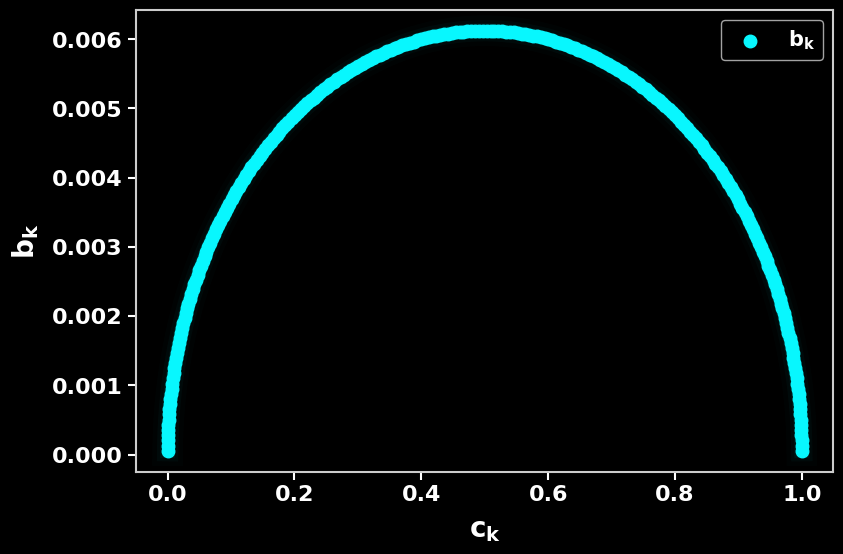

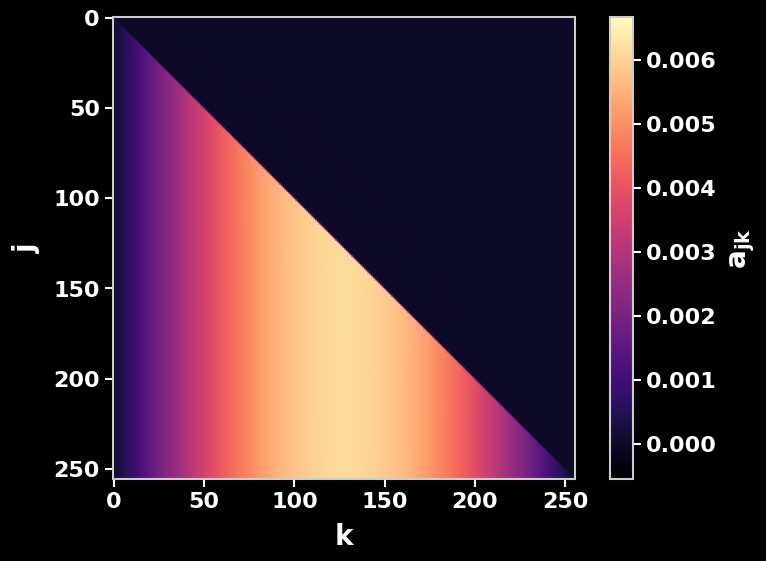

In [43]:
fig = plt.figure()
plt.scatter(irk_times, irk_weights[-1], label=r"$b_k$")
glow(irk_times, irk_weights[-1])
plt.xlabel(r'$c_k$')
plt.ylabel(r'$b_k$')
plt.legend(loc='best')
save('discrete_1_irk_weights_b')
plt.show()
plt.close()

fig = plt.figure()
plt.imshow(irk_weights[:-1], cmap='magma')
plt.colorbar(label=r'$a_{jk}$')
plt.xlabel(r'$k$')
plt.ylabel(r'$j$')
save('discrete_2_irk_weights_a')
plt.show()
plt.close()

Generate points of initial data by random sampling from a uniform distribution. The boundary data is only needed at the $q$ stage times and at $t_1$, i.e. at the times the network makes predictions for.

In [9]:
n_initial = 100


# draw initial data at t0 from uniform distribution
t_initial   = tf.ones((n_initial, 1), dtype=rtype) * t0
x_initial   = tf.random.uniform((n_initial, 1), xl, xr, dtype=rtype)
psi_initial = psi(x_initial, t_initial)

# every one of the q+1 outputs has to reproduce the initial data
# the network output is ordered as [Re(psi^{n+c_1}), ..., Re(psi^{n+1}), Im(psi^{n+c_1}), ..., Im(psi^{n+1})]
psi_initial_stages = tf.concat([tf.tile(psi_initial[:, 0:1], [1, q+1]),
                                tf.tile(psi_initial[:, 1:2], [1, q+1])], axis=1)


# boundary data at left and right boundary for all stage times
x_boundary   = tf.reshape(tf.stack([xl, xr]), (2, 1))
psi_l_stages = psi(tf.ones_like(t_stages) * xl, t_stages)
psi_r_stages = psi(tf.ones_like(t_stages) * xr, t_stages)
# bring into same order as network output, i.e. one row per boundary
psi_boundary = tf.concat([tf.stack([psi_l_stages[:, 0], psi_r_stages[:, 0]]),
                          tf.stack([psi_l_stages[:, 1], psi_r_stages[:, 1]])], axis=1)

x_initial.shape, psi_initial.shape, psi_initial_stages.shape, x_boundary.shape, psi_boundary.shape

(TensorShape([100, 1]),
 TensorShape([100, 2]),
 TensorShape([100, 514]),
 TensorShape([2, 1]),
 TensorShape([2, 514]))

The network output contains all stages at once. Extract a single stage $j$ as a complex vector of length 2 such that `get_density`, `get_real` and `get_imag` can be used as before. The final time $t_1$ corresponds to $j = q$.

In [10]:
def get_stage(psi_stages, j):
    return tf.stack([psi_stages[:, j], psi_stages[:, q+1+j]], axis=1)

def get_real_stages(psi_stages):
    return psi_stages[:, :q+1]

def get_imag_stages(psi_stages):
    return psi_stages[:, q+1:]

## Visualise initial and boundary data

In [11]:
n_linear     = 100

# Make sure that input times and positions are tensors of shape (n, 1) because that is what psi expects
xl_linear    = tf.ones((n_linear, 1)) * xl
xr_linear    = tf.ones((n_linear, 1)) * xr
t0_linear    = tf.ones((n_linear, 1)) * t0
t1_linear    = tf.ones((n_linear, 1)) * t1
x_linear     = tf.reshape(tf.linspace(xl, xr, n_linear), (n_linear, 1))
t_linear     = tf.reshape(tf.linspace(t0, t1, n_linear), (n_linear, 1))
# Reference for initial conditions
psi_0_linear = psi(x_linear, t0_linear)
psi_1_linear = psi(x_linear, t1_linear)
# Reference for boundary conditions
psi_l_linear = psi(xl_linear, t_linear)
psi_r_linear = psi(xr_linear, t_linear)

In contrast to the continuous time approach, the PINN only knows about the initial data at $t_0$ and the boundary data at the stage times. It has to predict the solution at $t_1$.

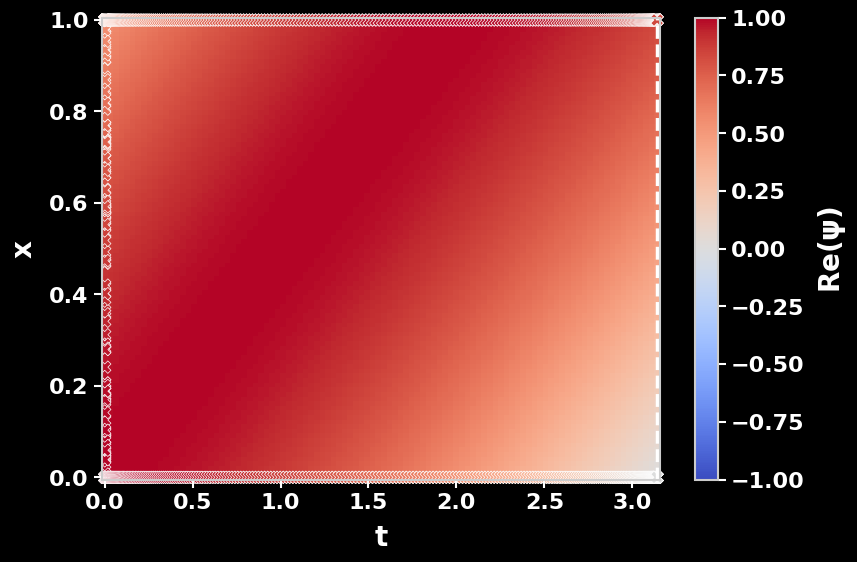

In [12]:
# Set up meshgrid of analytical solution for overview
xlin   = np.linspace(xl, xr, n_linear)
tlin   = np.linspace(t0, t1, n_linear)
xx, tt = np.meshgrid(xlin, tlin)
xxtt   = tf.cast(np.vstack([xx.flatten(),tt.flatten()]).T, rtype)
re_ana = get_real(psi(xxtt[:, 0:1], xxtt[:, 1:2])).numpy().reshape(n_linear, n_linear)

fig = plt.figure()
kw = dict(vmin=-1, vmax=1, cmap='coolwarm')
plt.pcolormesh(tt, xx, re_ana, shading='auto', **kw)
plt.colorbar(label=r'$Re(\psi)$')
plt.scatter(t_initial, x_initial, c=get_real(psi_initial), marker='X', edgecolors='white', linewidths=0.5, **kw)
plt.scatter(t_stages, tf.ones_like(t_stages) * xl, c=psi_l_stages[:, 0], marker='X', edgecolors='white', linewidths=0.5, clip_on=False, **kw)
plt.scatter(t_stages, tf.ones_like(t_stages) * xr, c=psi_r_stages[:, 0], marker='X', edgecolors='white', linewidths=0.5, clip_on=False, **kw)
plt.axvline(t1, color='white', linestyle='--')
plt.xlabel(r'$t$')
plt.ylabel(r'$x$')
save('discrete_3_overview')
plt.show()
plt.close()

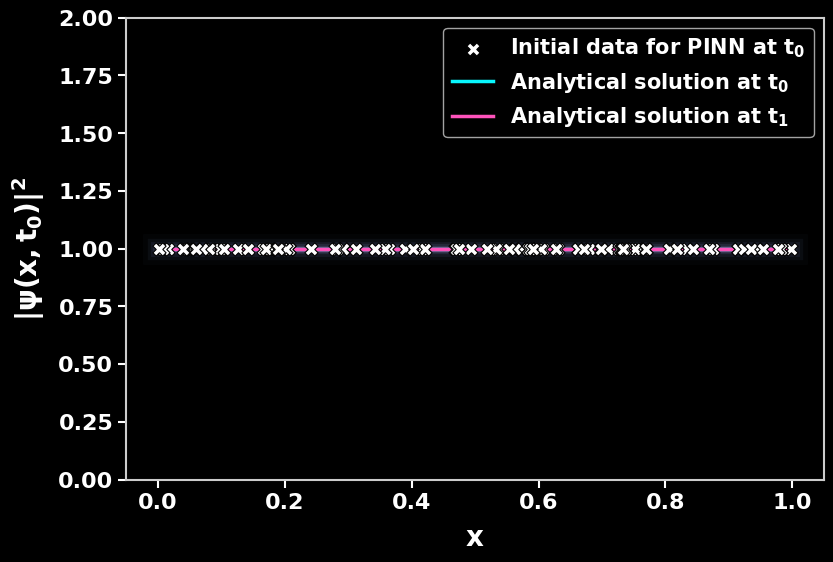

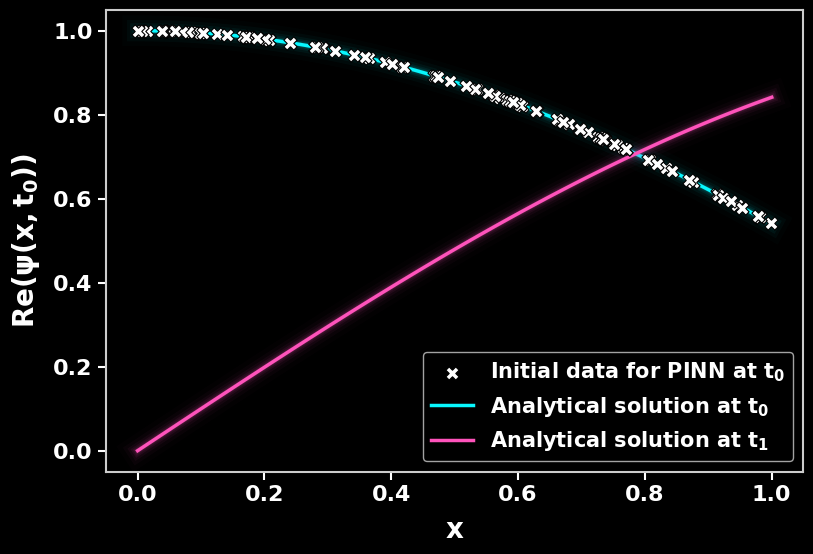

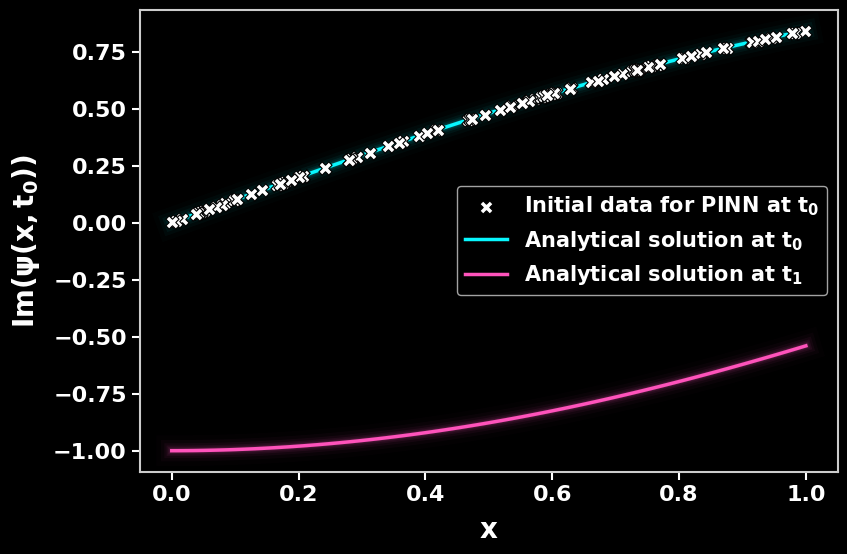

In [13]:
fig = plt.figure()
plt.scatter(x_initial, get_density(psi_initial), label="Initial data for PINN at $t_0$", **points)
glow(x_linear, get_density(psi_0_linear), label=r"Analytical solution at $t_0$")
glow(x_linear, get_density(psi_1_linear), label=r"Analytical solution at $t_1$")
plt.ylim(0, 2)
plt.xlabel(r'$x$')
plt.ylabel(r'$|\psi(x, t_0)|^2$')
plt.legend(loc='best')
save('discrete_4_initial_density')
plt.show()
plt.close()

fig = plt.figure()
plt.scatter(x_initial, get_real(psi_initial), label="Initial data for PINN at $t_0$", **points)
glow(x_linear, get_real(psi_0_linear), label=r"Analytical solution at $t_0$")
glow(x_linear, get_real(psi_1_linear), label=r"Analytical solution at $t_1$")
plt.xlabel(r'$x$')
plt.ylabel(r'$Re(\psi(x, t_0))$')
plt.legend(loc='best')
save('discrete_5_initial_real')
plt.show()
plt.close()

fig = plt.figure()
plt.scatter(x_initial, get_imag(psi_initial), label="Initial data for PINN at $t_0$", **points)
glow(x_linear, get_imag(psi_0_linear), label=r"Analytical solution at $t_0$")
glow(x_linear, get_imag(psi_1_linear), label=r"Analytical solution at $t_1$")
plt.xlabel(r'$x$')
plt.ylabel(r'$Im(\psi(x, t_0))$')
plt.legend(loc='best')
save('discrete_6_initial_imag')
plt.show()
plt.close()

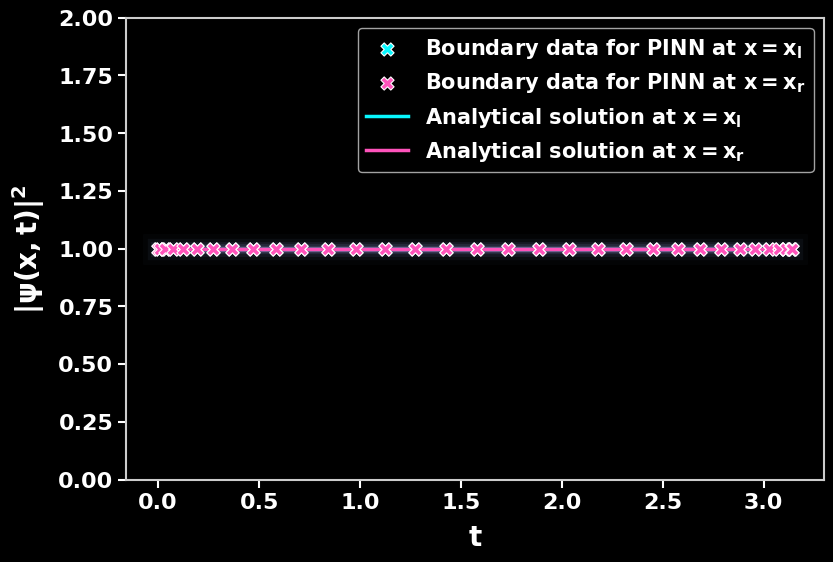

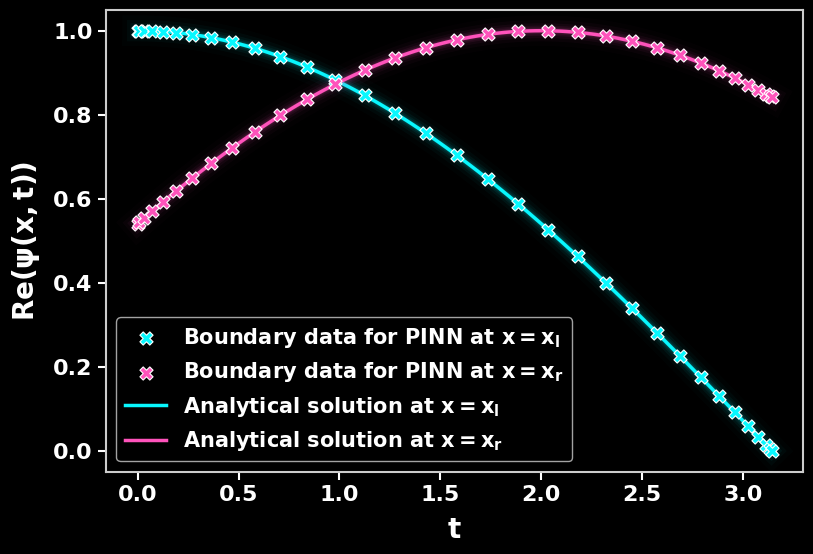

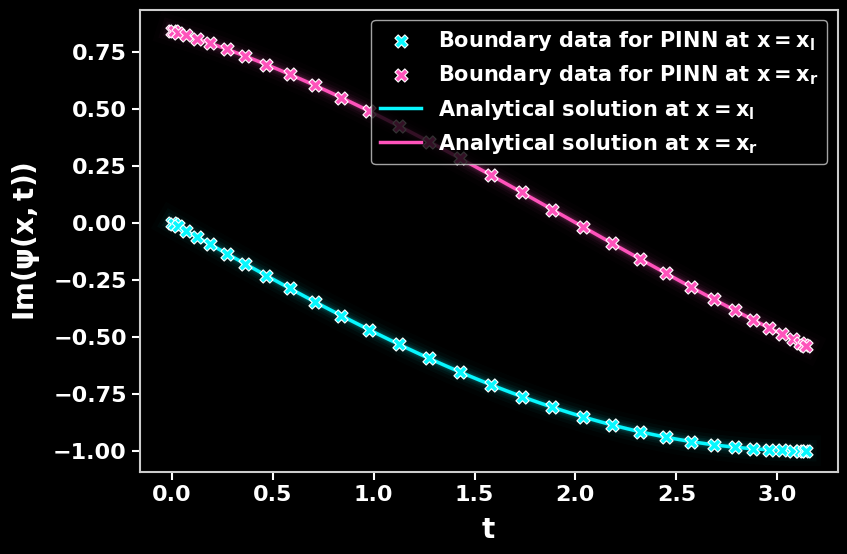

In [14]:
# only every 8th of the q stages is shown so that the analytical solution stays visible
fig = plt.figure()
plt.scatter(t_stages[::8], get_density(psi_l_stages)[::8], label=r"Boundary data for PINN at $x=x_l$", **dict(points, c=colors[0], edgecolors='white'))
plt.scatter(t_stages[::8], get_density(psi_r_stages)[::8], label=r"Boundary data for PINN at $x=x_r$", **dict(points, c=colors[1], edgecolors='white'))
glow(t_linear, get_density(psi_l_linear), label=r"Analytical solution at $x=x_l$")
glow(t_linear, get_density(psi_r_linear), label=r"Analytical solution at $x=x_r$")
plt.ylim(0, 2)
plt.xlabel(r'$t$')
plt.ylabel(r'$|\psi(x, t)|^2$')
plt.legend(loc='best')
save('discrete_7_boundary_density')
plt.show()
plt.close()

fig = plt.figure()
plt.scatter(t_stages[::8], get_real(psi_l_stages)[::8], label=r"Boundary data for PINN at $x=x_l$", **dict(points, c=colors[0], edgecolors='white'))
plt.scatter(t_stages[::8], get_real(psi_r_stages)[::8], label=r"Boundary data for PINN at $x=x_r$", **dict(points, c=colors[1], edgecolors='white'))
glow(t_linear, get_real(psi_l_linear), label=r"Analytical solution at $x=x_l$")
glow(t_linear, get_real(psi_r_linear), label=r"Analytical solution at $x=x_r$")
plt.xlabel(r'$t$')
plt.ylabel(r'$Re(\psi(x, t))$')
plt.legend(loc='best')
save('discrete_8_boundary_real')
plt.show()
plt.close()

fig = plt.figure()
plt.scatter(t_stages[::8], get_imag(psi_l_stages)[::8], label=r"Boundary data for PINN at $x=x_l$", **dict(points, c=colors[0], edgecolors='white'))
plt.scatter(t_stages[::8], get_imag(psi_r_stages)[::8], label=r"Boundary data for PINN at $x=x_r$", **dict(points, c=colors[1], edgecolors='white'))
glow(t_linear, get_imag(psi_l_linear), label=r"Analytical solution at $x=x_l$")
glow(t_linear, get_imag(psi_r_linear), label=r"Analytical solution at $x=x_r$")
plt.xlabel(r'$t$')
plt.ylabel(r'$Im(\psi(x, t))$')
plt.legend(loc='best')
save('discrete_9_boundary_imag')
plt.show()
plt.close()

## Create a neural network

Create simple fully connected feedforward model with $4$ hidden layers and $50$ neurons per layer. In contrast to the continuous time approach, the network only takes $x$ as input but has $2(q+1)$ outputs.

In [15]:
# Initialise fully-connected neural network
def init_model(num_hidden_layers=4, num_neurons_per_layer=50):
    model = tf.keras.Sequential()

    model.add(tf.keras.Input(1)) # 1D input, time is handled by the IRK scheme

    # normalise input to [-1, 1]
    scaling_layer = tf.keras.layers.Lambda(
        lambda x: 2.0*(x - xl)/(xr - xl) - 1.0
    )

    model.add(scaling_layer)

    for _ in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(num_neurons_per_layer, activation=tf.keras.activations.get("tanh"), kernel_initializer="glorot_normal"))

    model.add(tf.keras.layers.Dense(2*(q+1))) # real and imaginary part for each of the q stages and for t1

    return model

# Check whether model interface works as expected
m = init_model()
m(x_initial)

<tf.Tensor: shape=(100, 514), dtype=float32, numpy=
array([[ 0.03792627,  0.07300556,  0.02184879, ..., -0.02781003,
         0.02797684,  0.01441213],
       [ 0.05264647,  0.10135756,  0.03034011, ..., -0.03863053,
         0.03891741,  0.02006928],
       [-0.00655845, -0.01262277, -0.00377654, ...,  0.00480547,
        -0.004828  , -0.00248573],
       ...,
       [ 0.02914041,  0.05608975,  0.01678433, ..., -0.02136092,
         0.02147678,  0.01106033],
       [-0.04858974, -0.09354241, -0.02799924, ...,  0.03564636,
        -0.03589469, -0.01850345],
       [ 0.0761127 ,  0.14660132,  0.04388896, ..., -0.05592771,
         0.0565668 ,  0.02930157]], dtype=float32)>

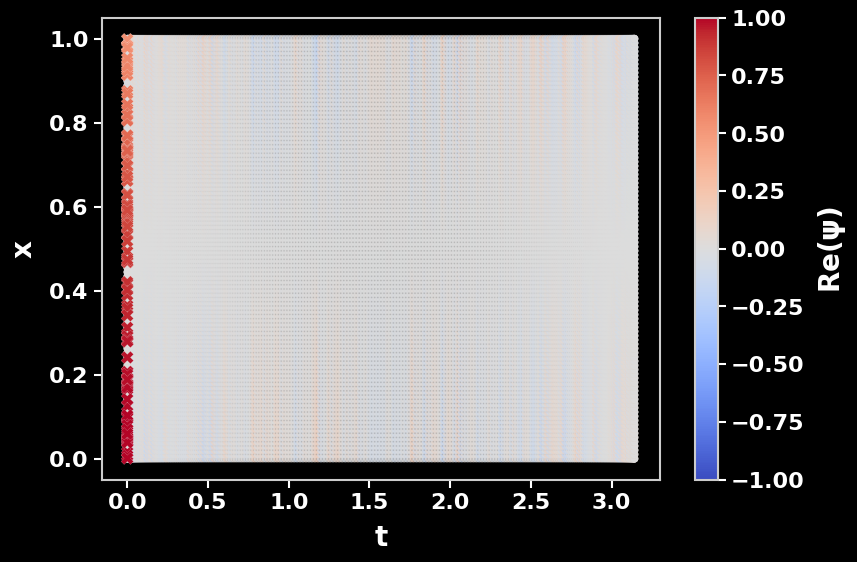

In [42]:
# Output of the untrained network at all stage times
tt_stages, xx_stages = np.meshgrid(t_stages, x_linear)

fig = plt.figure()
kw = dict(vmin=-1, vmax=1, cmap='coolwarm')
plt.scatter(tt_stages, xx_stages, c=get_real_stages(m(x_linear)), marker='.', alpha=0.6, **kw)
plt.scatter(t_initial, x_initial, c=get_real(psi_initial), marker='X', edgecolors='white',  linewidths=0.1, **kw)
plt.colorbar(label=r'$Re(\psi)$')

plt.xlabel(r'$t$')
plt.ylabel(r'$x$')
save('discrete_10_untrained_stages')
plt.show()

Compute the spatial derivatives of all stages and undo the IRK step to reconstruct the initial condition from every output.

In [17]:
def compute_initial_reconstruction(model, x):
    # Every output depends only on its own x, but tape.gradient would sum over all 2(q+1) outputs.
    # Dummy variable trick from fwd_gradients in Raissi's implementation: the gradient w.r.t. x weighted
    # with a dummy variable is linear in the dummy, so differentiating it w.r.t. the dummy
    # yields the derivatives of all outputs at once
    # Note: tf.autodiff.ForwardAccumulator would be the natural choice here, but backpropagating
    # through nested accumulators silently yields wrong gradients w.r.t. the weights inside tf.function
    dummy_1 = tf.ones((tf.shape(x)[0], 2*(q+1)), dtype=rtype)
    dummy_2 = tf.ones((tf.shape(x)[0], 2*(q+1)), dtype=rtype)

    # Nested tapes: each tape records the gradient computed by the tape inside of it
    # so that no gradient has to be called inside its own context
    with tf.GradientTape() as tape_dummy_2:
        tape_dummy_2.watch(dummy_2)
        with tf.GradientTape() as tape_x_2:
            tape_x_2.watch(x)
            with tf.GradientTape() as tape_dummy_1:
                tape_dummy_1.watch(dummy_1)
                with tf.GradientTape() as tape_x_1:
                    tape_x_1.watch(x)
                    psi_stages = model(x)
                g_1 = tape_x_1.gradient(psi_stages, x, output_gradients=dummy_1)
            psi_x = tape_dummy_1.gradient(g_1, dummy_1)
        g_2 = tape_x_2.gradient(psi_x, x, output_gradients=dummy_2)
    psi_xx = tape_dummy_2.gradient(g_2, dummy_2)

    # Split into real and imaginary parts, only the q stages enter N[psi] - not the final time t1
    re    = get_real_stages(psi_stages)
    im    = get_imag_stages(psi_stages)
    re_xx = get_real_stages(psi_xx)[:, :q]
    im_xx = get_imag_stages(psi_xx)[:, :q]

    # N[psi] = i hbar/(2m) psi_xx - i/hbar V psi
    # -> Re(N) = - hbar/(2m) Im(psi_xx) + Im(V psi)/hbar
    # -> Im(N) =   hbar/(2m) Re(psi_xx) - Re(V psi)/hbar
    N_re = - 0.5 * hbar / mass * im_xx
    N_im =   0.5 * hbar / mass * re_xx

    # Undo the IRK step: psi^n = psi^{n+c_j} - dt sum_k a_jk N[psi^{n+c_k}] for the stages
    # and psi^n = psi^{n+1} - dt sum_k b_k N[psi^{n+c_k}] for t1
    re0 = re - dt * tf.matmul(N_re, irk_weights, transpose_b=True)
    im0 = im - dt * tf.matmul(N_im, irk_weights, transpose_b=True)

    return tf.concat([re0, im0], axis=1)

# Check whether compute_initial_reconstruction works as expected
print(tf.reduce_mean(tf.square(compute_initial_reconstruction(init_model(), x_initial) - psi_initial_stages)))

tf.Tensor(0.5035529, shape=(), dtype=float32)


Compute loss by adding MSE of reconstructed initial data and of boundary data

In [18]:
def compute_loss(model, x_initial, psi_initial_stages, x_boundary, psi_boundary):
    loss  = tf.reduce_mean(tf.square(compute_initial_reconstruction(model, x_initial) - psi_initial_stages)) # Enforce PDE dynamics and initial conditions
    loss += tf.reduce_mean(tf.square(model(x_boundary) - psi_boundary))                                      # Enforce boundary conditions
    return loss

Compute loss and run backpropagation

In [19]:
def compute_gradient(model, x_initial, psi_initial_stages, x_boundary, psi_boundary):

    # Trainable variables are watched automatically; a single gradient call needs no persistent tape
    with tf.GradientTape() as tape:
        loss = compute_loss(model, x_initial, psi_initial_stages, x_boundary, psi_boundary)

    g = tape.gradient(loss, model.trainable_variables)

    return loss, g

Choose optimiser for model

In [20]:
model = init_model()

# We choose a piecewise decay of the learning rate, i.e., the
# step size in the gradient descent type algorithm
# the first 1000 steps use a learning rate of 0.01
# from 1000 - 3000: learning rate = 0.001
# from 3000 onwards: learning rate = 0.0005

lr = tf.keras.optimizers.schedules.PiecewiseConstantDecay([1000,3000],[1e-2,1e-3,5e-4])

# Choose the optimizer
optim = tf.keras.optimizers.Adam(learning_rate=lr)

Call model with points and values for initial and boundary conditions, compute loss, run backpropagation and run optimiser with gradients.

In [21]:
from time import time

@tf.function
def train_step():
    loss, grad_theta = compute_gradient(model, x_initial, psi_initial_stages, x_boundary, psi_boundary)

    optim.apply_gradients(zip(grad_theta, model.trainable_variables))

    return loss

N = 5000
hist = []

current_time = time()

for i in range(N+1):
    loss = train_step()
    hist.append(loss.numpy())

    if i%50 == 0:
        print('It {:05d}: loss = {:10.8e}'.format(i,loss))

# Print computation time
print('\nComputation time: {} seconds'.format(time()-current_time))

It 00000: loss = 1.00197303e+00
It 00050: loss = 1.75763923e-03
It 00100: loss = 1.57869785e-04
It 00150: loss = 3.49353696e-03
It 00200: loss = 8.78759383e-05
It 00250: loss = 3.73527437e-05
It 00300: loss = 2.86331098e-03
It 00350: loss = 2.75709099e-05
It 00400: loss = 1.85316567e-05
It 00450: loss = 4.95455693e-03
It 00500: loss = 1.55159541e-05
It 00550: loss = 1.11924437e-05
It 00600: loss = 4.30318905e-05
It 00650: loss = 1.14950017e-05
It 00700: loss = 1.41529576e-03
It 00750: loss = 1.54401732e-05
It 00800: loss = 1.19484263e-04
It 00850: loss = 1.13225709e-04
It 00900: loss = 5.30038551e-06
It 00950: loss = 3.88498709e-04
It 01000: loss = 7.59778823e-06
It 01050: loss = 3.58828697e-06
It 01100: loss = 3.48321532e-06
It 01150: loss = 3.41215878e-06
It 01200: loss = 3.34621882e-06
It 01250: loss = 3.28481542e-06
It 01300: loss = 3.22747587e-06
It 01350: loss = 3.17375429e-06
It 01400: loss = 3.12326529e-06
It 01450: loss = 3.07569439e-06
It 01500: loss = 3.03071761e-06
It 01550

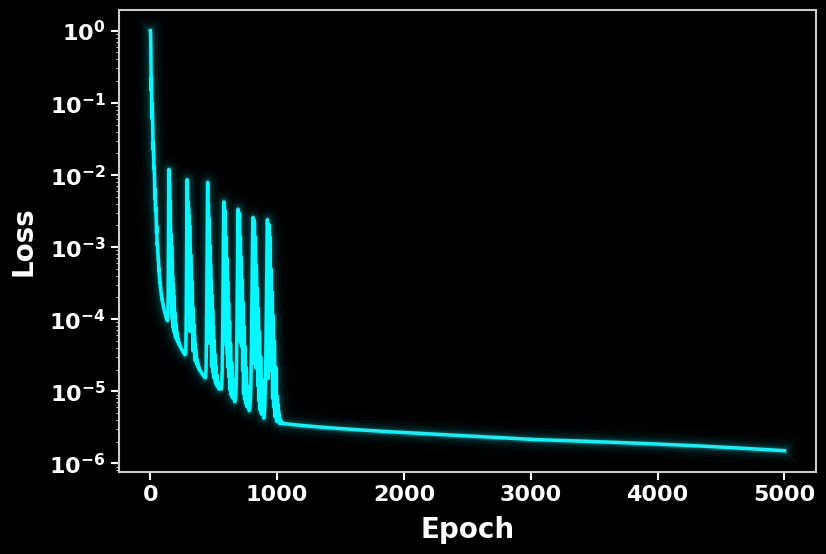

In [22]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.set_yscale('log')
glow(range(len(hist)), hist, ax=ax)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
save('discrete_11_loss_history')
plt.show()

## Check what model has learnt

### Check initial conditions

The initial condition is not an output of the network but is reconstructed from all $q+1$ outputs by undoing the IRK step. We show the reconstruction from the prediction at $t_1$.

In [23]:
psi_initial_pred = compute_initial_reconstruction(model, x_initial)
psi_initial_pred.shape

TensorShape([100, 514])

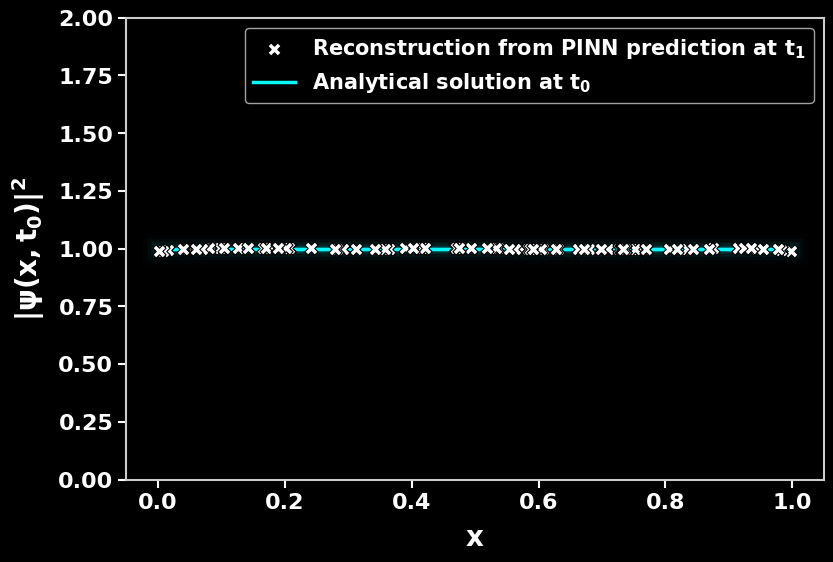

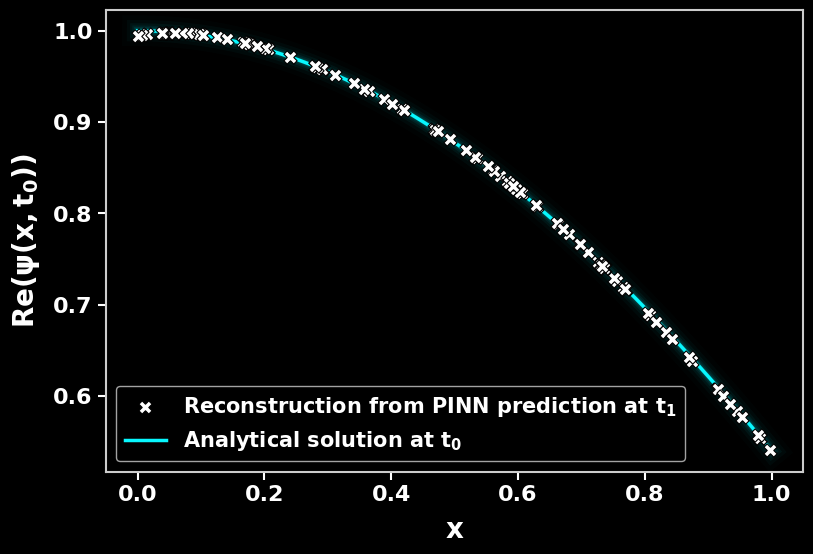

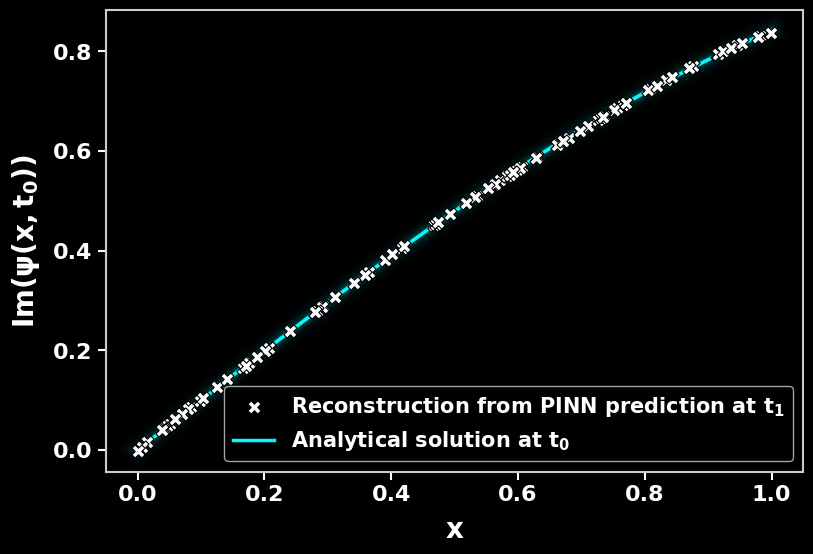

In [24]:
fig = plt.figure()
plt.scatter(x_initial, get_density(get_stage(psi_initial_pred, q)), label="Reconstruction from PINN prediction at $t_1$", **points)
glow(x_linear, get_density(psi_0_linear), label=r"Analytical solution at $t_0$")
plt.ylim(0, 2)
plt.xlabel(r'$x$')
plt.ylabel(r'$|\psi(x, t_0)|^2$')
plt.legend(loc='best')
save('discrete_12_pred_initial_density')
plt.show()
plt.close()

fig = plt.figure()
plt.scatter(x_initial, get_real(get_stage(psi_initial_pred, q)), label="Reconstruction from PINN prediction at $t_1$", **points)
glow(x_linear, get_real(psi_0_linear), label=r"Analytical solution at $t_0$")
plt.xlabel(r'$x$')
plt.ylabel(r'$Re(\psi(x, t_0))$')
plt.legend(loc='best')
save('discrete_13_pred_initial_real')
plt.show()
plt.close()

fig = plt.figure()
plt.scatter(x_initial, get_imag(get_stage(psi_initial_pred, q)), label="Reconstruction from PINN prediction at $t_1$", **points)
glow(x_linear, get_imag(psi_0_linear), label=r"Analytical solution at $t_0$")
plt.xlabel(r'$x$')
plt.ylabel(r'$Im(\psi(x, t_0))$')
plt.legend(loc='best')
save('discrete_14_pred_initial_imag')
plt.show()
plt.close()

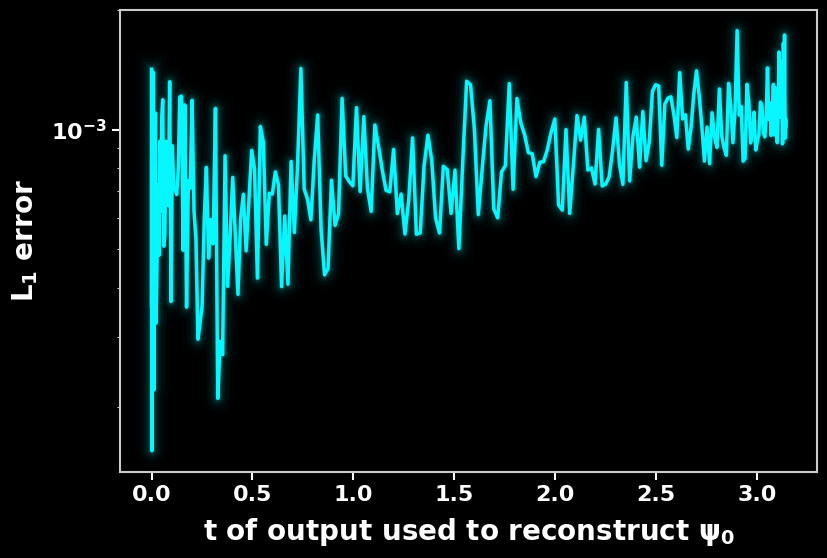

In [25]:
# L1 error of the reconstructed initial condition, separately for each of the q+1 outputs
abs_error_initial = tf.abs(psi_initial_pred - psi_initial_stages)
error_initial     = 0.5 * tf.reduce_mean(get_real_stages(abs_error_initial) + get_imag_stages(abs_error_initial), axis=0)

fig = plt.figure()
ax = plt.gca()
ax.set_yscale('log')
glow(t_stages, error_initial, ax=ax)
plt.xlabel(r'$t$ of output used to reconstruct $\psi_0$')
plt.ylabel(r'$L_1$ error')
save('discrete_15_pred_initial_error')
plt.show()
plt.close()

### Check boundary conditions

In [26]:
psi_boundary_pred = model(x_boundary)
psi_l_stages_pred = tf.stack([get_real_stages(psi_boundary_pred)[0], get_imag_stages(psi_boundary_pred)[0]], axis=1)
psi_r_stages_pred = tf.stack([get_real_stages(psi_boundary_pred)[1], get_imag_stages(psi_boundary_pred)[1]], axis=1)
psi_boundary_pred.shape, psi_l_stages_pred.shape

(TensorShape([2, 514]), TensorShape([257, 2]))

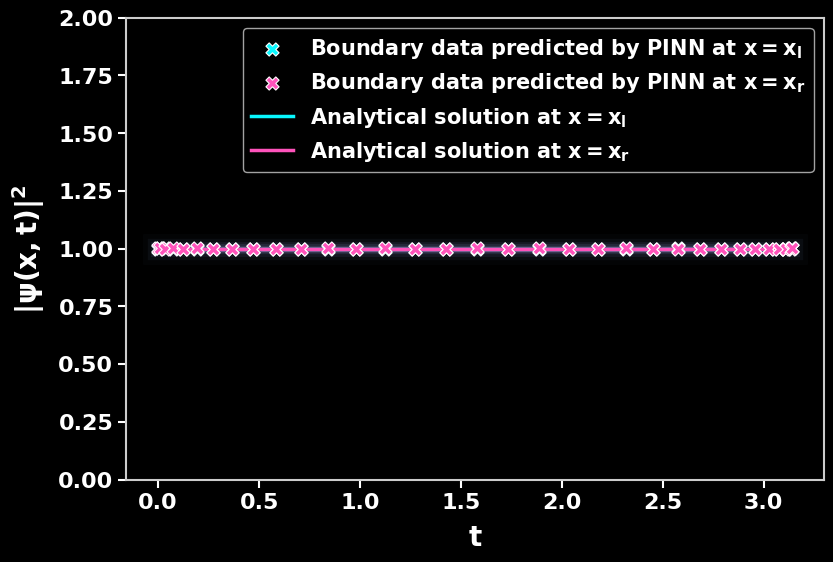

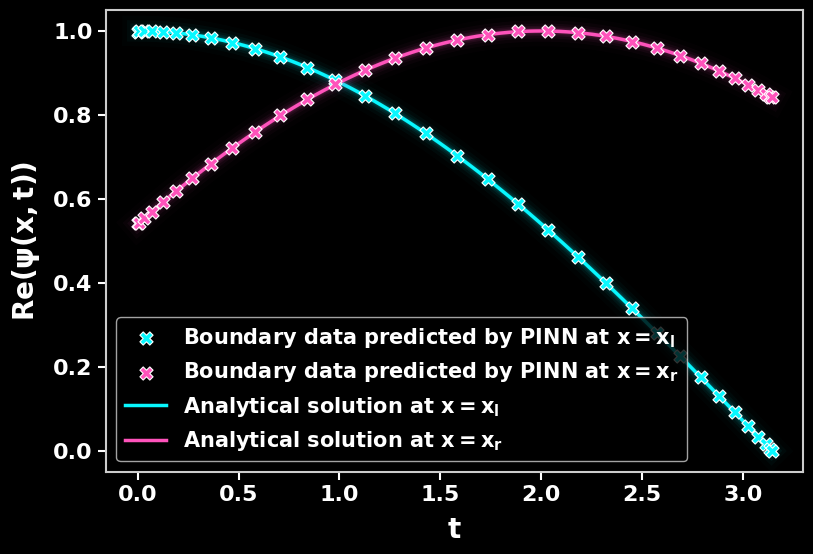

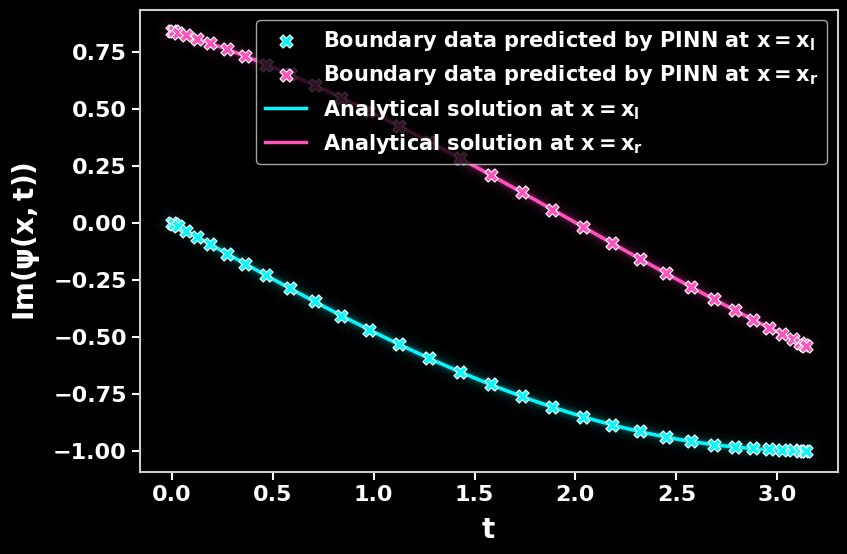

In [27]:
# only every 8th of the q stages is shown so that the analytical solution stays visible
fig = plt.figure()
plt.scatter(t_stages[::8], get_density(psi_l_stages_pred)[::8], label=r"Boundary data predicted by PINN at $x=x_l$", **dict(points, c=colors[0], edgecolors='white'))
plt.scatter(t_stages[::8], get_density(psi_r_stages_pred)[::8], label=r"Boundary data predicted by PINN at $x=x_r$", **dict(points, c=colors[1], edgecolors='white'))
glow(t_linear, get_density(psi_l_linear), label=r"Analytical solution at $x=x_l$")
glow(t_linear, get_density(psi_r_linear), label=r"Analytical solution at $x=x_r$")
plt.ylim(0, 2)
plt.xlabel(r'$t$')
plt.ylabel(r'$|\psi(x, t)|^2$')
plt.legend(loc='best')
save('discrete_16_pred_boundary_density')
plt.show()
plt.close()

fig = plt.figure()
plt.scatter(t_stages[::8], get_real(psi_l_stages_pred)[::8], label=r"Boundary data predicted by PINN at $x=x_l$", **dict(points, c=colors[0], edgecolors='white'))
plt.scatter(t_stages[::8], get_real(psi_r_stages_pred)[::8], label=r"Boundary data predicted by PINN at $x=x_r$", **dict(points, c=colors[1], edgecolors='white'))
glow(t_linear, get_real(psi_l_linear), label=r"Analytical solution at $x=x_l$")
glow(t_linear, get_real(psi_r_linear), label=r"Analytical solution at $x=x_r$")
plt.xlabel(r'$t$')
plt.ylabel(r'$Re(\psi(x, t))$')
plt.legend(loc='best')
save('discrete_17_pred_boundary_real')
plt.show()
plt.close()

fig = plt.figure()
plt.scatter(t_stages[::8], get_imag(psi_l_stages_pred)[::8], label=r"Boundary data predicted by PINN at $x=x_l$", **dict(points, c=colors[0], edgecolors='white'))
plt.scatter(t_stages[::8], get_imag(psi_r_stages_pred)[::8], label=r"Boundary data predicted by PINN at $x=x_r$", **dict(points, c=colors[1], edgecolors='white'))
glow(t_linear, get_imag(psi_l_linear), label=r"Analytical solution at $x=x_l$")
glow(t_linear, get_imag(psi_r_linear), label=r"Analytical solution at $x=x_r$")
plt.xlabel(r'$t$')
plt.ylabel(r'$Im(\psi(x, t))$')
plt.legend(loc='best')
save('discrete_18_pred_boundary_imag')
plt.show()
plt.close()

The model also seems to have successfully learnt to describe the boundary conditions.

### Check prediction at $t_1$

This is the actual result of the discrete time approach: the PINN only got data at $t_0$ and on the boundary and predicts the solution at $t_1$.

In [28]:
psi_1_pred = get_stage(model(x_linear), q)
psi_1_pred.shape

TensorShape([100, 2])

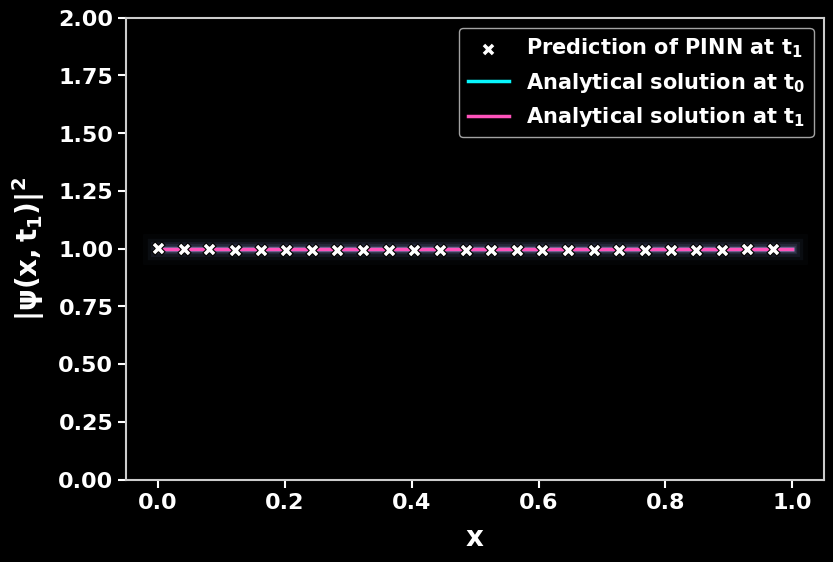

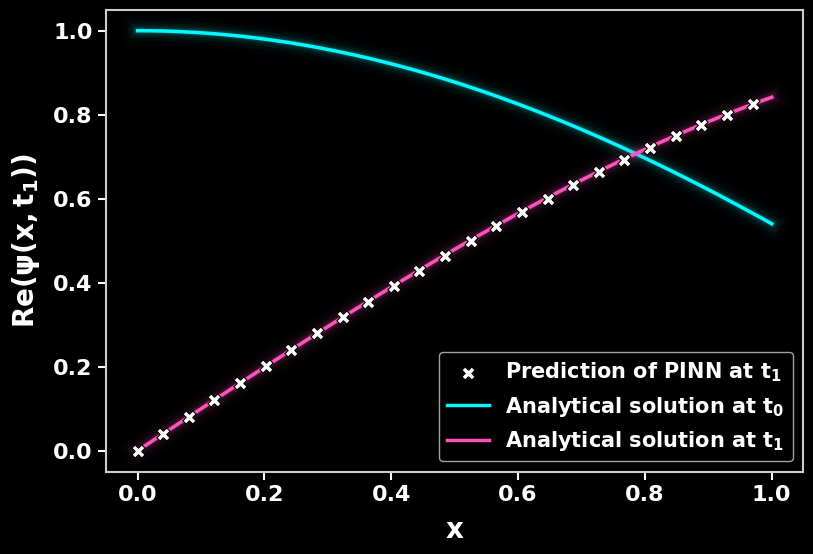

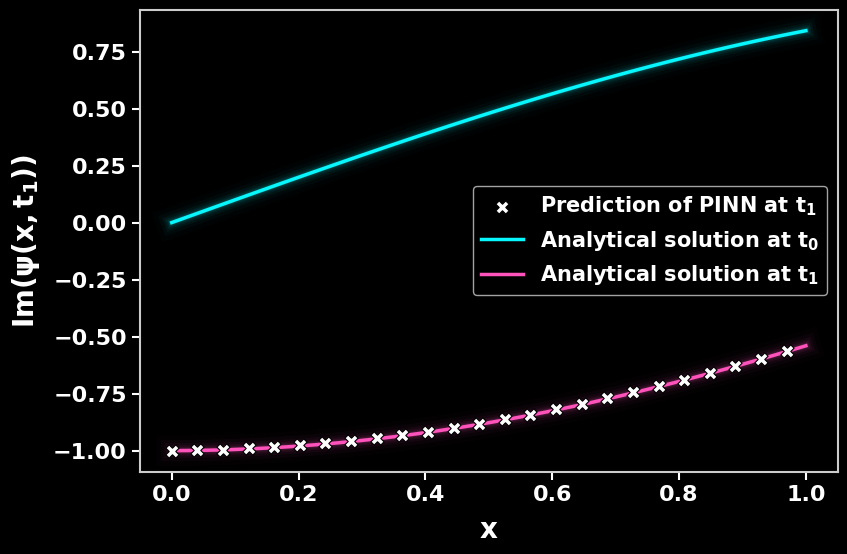

In [29]:
# only every 4th point is shown so that the analytical solution stays visible
fig = plt.figure()
plt.scatter(x_linear[::4], get_density(psi_1_pred)[::4], label="Prediction of PINN at $t_1$", **points)
glow(x_linear, get_density(psi_0_linear), label=r"Analytical solution at $t_0$")
glow(x_linear, get_density(psi_1_linear), label=r"Analytical solution at $t_1$")
plt.ylim(0, 2)
plt.xlabel(r'$x$')
plt.ylabel(r'$|\psi(x, t_1)|^2$')
plt.legend(loc='best')
save('discrete_19_pred_final_density')
plt.show()
plt.close()

fig = plt.figure()
plt.scatter(x_linear[::4], get_real(psi_1_pred)[::4], label="Prediction of PINN at $t_1$", **points)
glow(x_linear, get_real(psi_0_linear), label=r"Analytical solution at $t_0$")
glow(x_linear, get_real(psi_1_linear), label=r"Analytical solution at $t_1$")
plt.xlabel(r'$x$')
plt.ylabel(r'$Re(\psi(x, t_1))$')
plt.legend(loc='best')
save('discrete_20_pred_final_real')
plt.show()
plt.close()

fig = plt.figure()
plt.scatter(x_linear[::4], get_imag(psi_1_pred)[::4], label="Prediction of PINN at $t_1$", **points)
glow(x_linear, get_imag(psi_0_linear), label=r"Analytical solution at $t_0$")
glow(x_linear, get_imag(psi_1_linear), label=r"Analytical solution at $t_1$")
plt.xlabel(r'$x$')
plt.ylabel(r'$Im(\psi(x, t_1))$')
plt.legend(loc='best')
save('discrete_21_pred_final_imag')
plt.show()
plt.close()

In [30]:
n_test = 10000

# draw test points at t1 from uniform distribution
t_test  = tf.ones((n_test, 1), dtype=rtype) * t1
x_test  = tf.random.uniform((n_test,1), xl, xr, dtype=rtype)

psi_test_ana  = psi(x_test, t_test)
psi_test_pred = get_stage(model(x_test), q)
print("L1 error on test points at t1: ", tf.reduce_mean(tf.abs(psi_test_ana - psi_test_pred)).numpy())
print("Relative L2 error on test points at t1: ", (tf.norm(psi_test_ana - psi_test_pred) / tf.norm(psi_test_ana)).numpy())
print("Avg density of prediction at t1", tf.reduce_mean(get_density(psi_test_pred)).numpy())

L1 error on test points at t1:  0.0014813903
Relative L2 error on test points at t1:  0.0024178931
Avg density of prediction at t1 0.99563134


### Check inside domain

As a by-product, the network also predicts the solution at the $q$ stage times inside the time step.

In [31]:
psi_stages_pred = model(x_linear)
re_stages_pred  = get_real_stages(psi_stages_pred).numpy()
im_stages_pred  = get_imag_stages(psi_stages_pred).numpy()

psi_stages_ana  = psi(tf.reshape(tf.cast(xx_stages, rtype), (-1, 1)), tf.reshape(tf.cast(tt_stages, rtype), (-1, 1))).numpy()
re_stages_ana   = psi_stages_ana[:, 0].reshape(xx_stages.shape)
im_stages_ana   = psi_stages_ana[:, 1].reshape(xx_stages.shape)

print("L1 error at stage times: ", 0.5 * np.mean(np.abs(re_stages_ana - re_stages_pred) + np.abs(im_stages_ana - im_stages_pred)))

L1 error at stage times:  0.0009608085


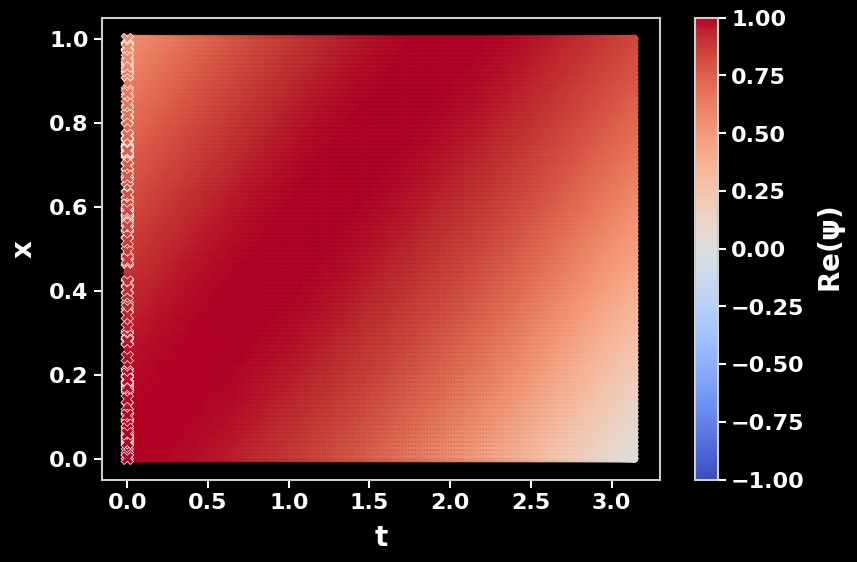

In [32]:
fig = plt.figure()
kw = dict(vmin=-1, vmax=1, cmap='coolwarm')
plt.scatter(tt_stages, xx_stages, c=re_stages_pred, marker='.', alpha=0.6, **kw)
plt.scatter(t_initial, x_initial, c=get_real(psi_initial), marker='X', edgecolors='white', linewidths=0.5, **kw)
plt.colorbar(label=r'$Re(\psi)$')

plt.xlabel(r'$t$')
plt.ylabel(r'$x$')
save('discrete_22_pred_stages')
plt.show()

This very much looks like the real part of a plane wave at the stage times.

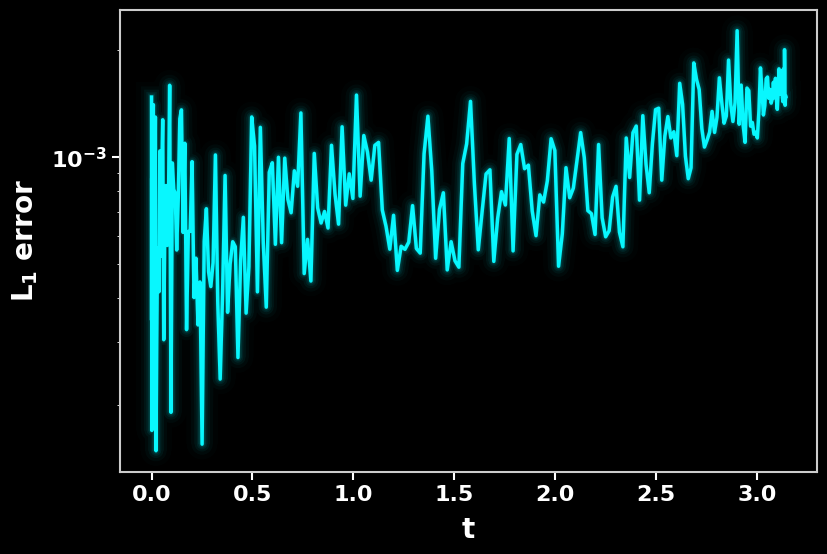

In [33]:
# L1 error of the prediction, separately for each stage and t1
error_stages = 0.5 * np.mean(np.abs(re_stages_ana - re_stages_pred) + np.abs(im_stages_ana - im_stages_pred), axis=0)

fig = plt.figure()
ax = plt.gca()
ax.set_yscale('log')
glow(t_stages, error_stages, ax=ax)
plt.xlabel(r'$t$')
plt.ylabel(r'$L_1$ error')
save('discrete_23_pred_stages_error')
plt.show()
plt.close()

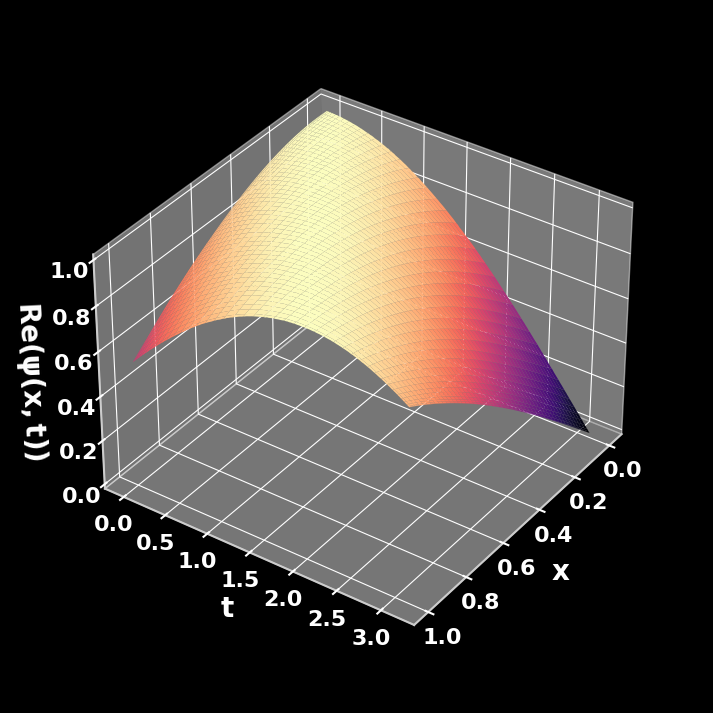

In [34]:
from mpl_toolkits.mplot3d import Axes3D

# Surface plot of solution at the stage times
fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(xx_stages, tt_stages, re_stages_pred, cmap='magma')

ax.view_init(35,35)
ax.set_xlabel('$x$', labelpad=12)
ax.set_ylabel('$t$', labelpad=12)
ax.set_zlabel(r'$Re(\psi(x, t))$', labelpad=12)
ax.set_box_aspect(None, zoom=0.85)          # shrink the 3D box so labels fit

save('discrete_24_pred_surface_real')
plt.show()